In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def calc_toks_flops(df):
    """Calculate tokens and FLOPs for a given DataFrame of training logs.
     Args:
        df (pd.DataFrame): DataFrame containing training logs with columns 'iteration', 'gbsz', and 'non_embed_params (B)'.
    Returns:
        pd.DataFrame: DataFrame with additional columns for tokens and FLOPs.
    """
    df["tokens (B)"] = df["iteration"] * df["gbsz"] * 4096 / 1e9
    df["compute (exaFLOPs)"] = 6 * df["tokens (B)"] * df["non_embed_params (B)"]
    df["compute (FLOPs)"] = df["compute (exaFLOPs)"] * 1e18
    df.sort_values("tokens (B)", inplace=True)

    return df

In [36]:
def plot_loss_curves(
    models,
    x_axis,
    title_base,
    save_path,
    style_fn=None,
    y_key="lm_loss",
    figsize=(14, 4),
):
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    titles = [title_base, f"{title_base} (log)"]
    fig.suptitle(title_base, fontsize=16)

    if x_axis == "tokens":
        x_key = "tokens (B)"
        scale = 1e9
        x_label = "Tokens ($D$)"
    elif x_axis == "compute":
        x_key = "compute (FLOPs)"
        scale = 1
        x_label = "FLOPs ($C$)"
    else:
        raise ValueError("x_axis must be either 'tokens' or 'compute'")

    for ax, title in zip(axes, titles):
        for label, data in models.items():
            style = {} if style_fn is None else style_fn(label, data)

            ax.plot(
                data[x_key] * scale,
                data[y_key],
                marker="o",
                label=label,
                **style
            )

        ax.set_xlabel(x_label)
        ax.set_ylabel("loss")

    axes[1].grid(True)
    axes[1].legend()
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")

    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

### Opensci reference models
Loss on independent validation set based on optimal hyperparameters, manually selected from Niccolo's grids. Thus, mistakes can occur!


The number of parameters and non-embedding parameters are taken from LUMI, arbitrary Niccolo's runs, megatron logs by looking at:
- non-embedding: `Number of parameters in transformer layers in billions:  0.91`
- total (incl. embedding): `Total number of parameters in billions: 0.98`
- total: `number of parameters on (tensor, pipeline) model parallel rank (0, 0): 124684992`

In [4]:
### Total number of parameters (including embedding) is actually reported to be 130M, 
# but the non-embedding parameters are 100M and embedding parameters are 30M. 
# We report the latter, to remain consistent with the naming convention.
opensci_130M = pd.DataFrame({
    "iteration": [45777, 91553, 38147, 57221, 95368, 152588, 114441, 190735, 286103],
    "lm_loss": [2.7129, 2.6497, 2.6048, 2.5736, 2.5409, 2.5162, 2.4975, 2.4772, 2.4647],
    "params (B)": [0.13] * 9,
    "non_embed_params (B)": [0.10] * 9,
    "params": [124684992] * 9,
    "gbsz": [32, 32, 128, 128, 128, 128, 256, 256, 256], 
    "lr": [0.001, 0.001, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002],
    "model_name": ["opensci-ref-130M"] * 9,

})
opensci_130M = calc_toks_flops(opensci_130M)
opensci_130M.head(2)

,iteration,lm_loss,params (B),non_embed_params (B),params,gbsz,lr,model_name,tokens (B),compute (exaFLOPs),compute (FLOPs)
0,45777,2.7129,0.13,0.1,124684992,32,0.001,opensci-ref-130M,6.000083,3.600050,3.600050e+18
1,91553,2.6497,0.13,0.1,124684992,32,0.001,opensci-ref-130M,12.000035,7.200021,7.200021e+18


In [5]:
opensci_300M = pd.DataFrame({
    "iteration": [22889, 45777, 76294, 114441, 47684, 76294, 114441, 95368, 143052],
    "lm_loss": [2.5723, 2.4939, 2.448, 2.4158, 2.379, 2.3457, 2.321, 2.2952, 2.2769],
    "params (B)": [0.3] * 9,
    "non_embed_params (B)": [0.26] * 9,
    "params": [302245760] * 9,
    "gbsz": [64, 64, 64, 64, 256, 256, 256, 512, 512], 
    "lr": [0.0005, 0.0005, 0.0005, 0.0005, 0.002, 0.002, 0.002, 0.002, 0.002],
    "model_name": ["opensci-300M"] * 9

})
opensci_300M = calc_toks_flops(opensci_300M)
opensci_300M.head(2)

,iteration,lm_loss,params (B),non_embed_params (B),params,gbsz,lr,model_name,tokens (B),compute (exaFLOPs),compute (FLOPs)
0,22889,2.5723,0.3,0.26,302245760,64,0.0005,opensci-300M,6.000214,9.360334,9.360334e+18
1,45777,2.4939,0.3,0.26,302245760,64,0.0005,opensci-300M,12.000166,18.720259,1.872026e+19


In [6]:
opensci_600M = pd.DataFrame({
    "iteration": [22889, 22889, 38147, 57221, 95368, 152588, 57221, 95368, 143052],
    "lm_loss": [2.4798, 2.3996, 2.3477, 2.3112, 2.2696, 2.2357, 2.211, 2.1802, 2.1599],
    "params (B)": [0.59] * 9,
    "non_embed_params (B)": [0.52] * 9,
    "params": [589064960] * 9,
    "gbsz": [64, 128, 128, 128, 128, 128, 512, 512, 512], 
    "lr": [0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.002, 0.002, 0.002],
    "model_name": ["opensci-600M"] * 9

})
opensci_600M = calc_toks_flops(opensci_600M)
opensci_600M.head(2)

,iteration,lm_loss,params (B),non_embed_params (B),params,gbsz,lr,model_name,tokens (B),compute (exaFLOPs),compute (FLOPs)
0,22889,2.4798,0.59,0.52,589064960,64,0.001,opensci-600M,6.000214,18.720668,1.872067e+19
1,22889,2.3996,0.59,0.52,589064960,128,0.001,opensci-600M,12.000428,37.441335,3.744134e+19


In [7]:
opensci_1B = pd.DataFrame({
    "iteration": [11445, 22889, 38147, 57221, 95368, 152588, 228882, 95368, 143052],
    "lm_loss": [2.4428, 2.3394, 2.2815, 2.243, 2.2003, 2.1646, 2.1368, 2.1095, 2.0861],
    "params (B)": [0.98] * 9,
    "non_embed_params (B)": [0.91] * 9,
    "params": [983794176] * 9,
    "gbsz": [128, 128, 128, 128, 128, 128, 128, 512, 512], 
    "lr": [0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.002, 0.002],
    "model_name": ["opensci-1B"] * 9

})
opensci_1B = calc_toks_flops(opensci_1B)
opensci_1B.head(2)

,iteration,lm_loss,params (B),non_embed_params (B),params,gbsz,lr,model_name,tokens (B),compute (exaFLOPs),compute (FLOPs)
0,11445,2.4428,0.98,0.91,983794176,128,0.0005,opensci-1B,6.000476,32.762600,3.276260e+19
1,22889,2.3394,0.98,0.91,983794176,128,0.0005,opensci-1B,12.000428,65.522337,6.552234e+19


### Replication experiment

In [8]:
### Opensci Original LUMI 130 LR 0.002, GBSZ 128 on Leonardo
### Total number of parameters (including embedding) is actually reported to be 130M, 
# but the non-embedding parameters are 100M and embedding parameters are 30M. 
# We report the latter, to remain consistent with the naming convention.
opensci_130M_50BT_lr002_gbsz128 = pd.DataFrame({
    
    "iteration": [11445, 22889, 38147, 57221, 95368],
    "lm_loss": [2.7296, 2.6512, 2.6048, 2.5736, 2.5409],
    "params (B)": [0.13] * 5,   
    "non_embed_params (B)": [0.10] * 5,
    "params": [124684992] * 5,
    "gbsz": [128] * 5,
    "lr": [0.002] * 5,
    "model_name": ["opensci-130M-50BT-lr002-gbsz128"] * 5
})
opensci_130M_50BT_lr002_gbsz128 = calc_toks_flops(opensci_130M_50BT_lr002_gbsz128)
opensci_130M_50BT_lr002_gbsz128.head(2)

,iteration,lm_loss,params (B),non_embed_params (B),params,gbsz,lr,model_name,tokens (B),compute (exaFLOPs),compute (FLOPs)
0,11445,2.7296,0.13,0.1,124684992,128,0.002,opensci-130M-50BT-lr002-gbsz128,6.000476,3.600286,3.600286e+18
1,22889,2.6512,0.13,0.1,124684992,128,0.002,opensci-130M-50BT-lr002-gbsz128,12.000428,7.200257,7.200257e+18


In [9]:
opensci_replication_130M_50BT_lr002_gbsz128 = pd.read_csv("results/eval_opensci_130M_50BT/val_loss_summary.csv")
opensci_replication_130M_50BT_lr002_gbsz128["gbsz"] = 128
opensci_replication_130M_50BT_lr002_gbsz128["lr"] = 0.002
opensci_replication_130M_50BT_lr002_gbsz128["non_embed_params (B)"] = 0.10
opensci_replication_130M_50BT_lr002_gbsz128["params (B)"] = 0.13
opensci_replication_130M_50BT_lr002_gbsz128["params"] = 124684992
opensci_replication_130M_50BT_lr002_gbsz128["model_name"] = "opensci-replication-130M-50BT-lr002-gbsz128"
opensci_replication_130M_50BT_lr002_gbsz128 = calc_toks_flops(opensci_replication_130M_50BT_lr002_gbsz128)
opensci_replication_130M_50BT_lr002_gbsz128.head(2)

,run_name,iteration,lm_loss,lm_loss_ppl,gbsz,lr,non_embed_params (B),params (B),params,model_name,tokens (B),compute (exaFLOPs),compute (FLOPs)
4,eval_opensci_130M_50BT_lr0.002_gbsz128_beta20....,11445,2.718182,15.15275,128,0.002,0.1,0.13,124684992,opensci-replication-130M-50BT-lr002-gbsz128,6.000476,3.600286,3.600286e+18
0,eval_opensci_130M_50BT_lr0.002_gbsz128_beta20....,22889,2.641536,14.03475,128,0.002,0.1,0.13,124684992,opensci-replication-130M-50BT-lr002-gbsz128,12.000428,7.200257,7.200257e+18


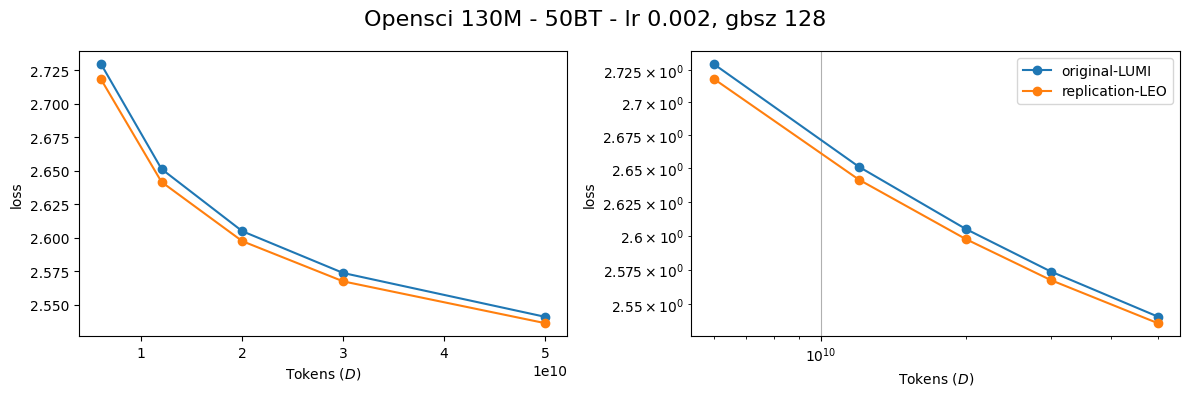

In [37]:
plot_loss_curves(
    models={
        "original-LUMI": opensci_130M_50BT_lr002_gbsz128,
        "replication-LEO": opensci_replication_130M_50BT_lr002_gbsz128,
    },
    x_axis="tokens",
    title_base='Opensci 130M - 50BT - lr 0.002, gbsz 128',
    save_path="figures/token_loss_replication_opensci_130M_50BT.png",
    figsize=(12, 4)
)

#### Second, exact replication to obtain variance

In [11]:
opensci_replication2_130M_50BT_lr002_gbsz128 = pd.read_csv("results/eval_opensci_130M_50BT2/val_loss_summary.csv")
opensci_replication2_130M_50BT_lr002_gbsz128["gbsz"] = 128
opensci_replication2_130M_50BT_lr002_gbsz128["lr"] = 0.002
opensci_replication2_130M_50BT_lr002_gbsz128["non_embed_params (B)"] = 0.10
opensci_replication2_130M_50BT_lr002_gbsz128["params (B)"] = 0.13
opensci_replication2_130M_50BT_lr002_gbsz128["params"] = 124684992
opensci_replication2_130M_50BT_lr002_gbsz128["model_name"] = "opensci-replication2-130M-50BT-lr002-gbsz128"
opensci_replication2_130M_50BT_lr002_gbsz128 = calc_toks_flops(opensci_replication2_130M_50BT_lr002_gbsz128)
opensci_replication2_130M_50BT_lr002_gbsz128.head(2)

,run_name,iteration,lm_loss,lm_loss_ppl,gbsz,lr,non_embed_params (B),params (B),params,model_name,tokens (B),compute (exaFLOPs),compute (FLOPs)
4,eval_opensci_130M_50BT_lr0.002_gbsz128_beta20....,11445,2.725940,15.27076,128,0.002,0.1,0.13,124684992,opensci-replication2-130M-50BT-lr002-gbsz128,6.000476,3.600286,3.600286e+18
0,eval_opensci_130M_50BT_lr0.002_gbsz128_beta20....,22889,2.651504,14.17534,128,0.002,0.1,0.13,124684992,opensci-replication2-130M-50BT-lr002-gbsz128,12.000428,7.200257,7.200257e+18


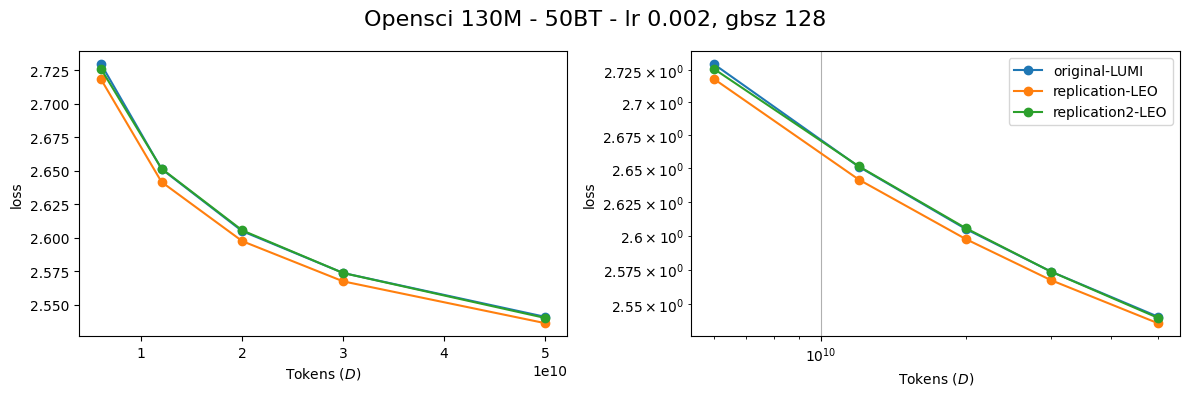

In [38]:
plot_loss_curves(
    models={
        "original-LUMI": opensci_130M_50BT_lr002_gbsz128,
        "replication-LEO": opensci_replication_130M_50BT_lr002_gbsz128,
        "replication2-LEO": opensci_replication2_130M_50BT_lr002_gbsz128,
    },
    x_axis="tokens",
    title_base='Opensci 130M - 50BT - lr 0.002, gbsz 128',
    save_path="figures/token_loss_replication2_opensci_130M_50BT.png",
    figsize=(12, 4)
)

### No bias experiment

In [28]:
opensci_no_bias_130M_50BT_lr002_gbsz128 = pd.read_csv("results/tests/eval_opensci_no_bias_130M_50BT/val_loss_summary.csv")
opensci_no_bias_130M_50BT_lr002_gbsz128["gbsz"] = 128
opensci_no_bias_130M_50BT_lr002_gbsz128["lr"] = 0.002
opensci_no_bias_130M_50BT_lr002_gbsz128["non_embed_params (B)"] = 0.10
opensci_no_bias_130M_50BT_lr002_gbsz128["params (B)"] = 0.13
opensci_no_bias_130M_50BT_lr002_gbsz128["parameters"] = 124550208
opensci_no_bias_130M_50BT_lr002_gbsz128["model_name"] = "opensci-no-bias-130M-50BT-lr002-gbsz128"
opensci_no_bias_130M_50BT_lr002_gbsz128 = calc_toks_flops(opensci_no_bias_130M_50BT_lr002_gbsz128)
opensci_no_bias_130M_50BT_lr002_gbsz128.head(2)

,run_name,iteration,lm_loss,lm_loss_ppl,gbsz,lr,non_embed_params (B),params (B),parameters,model_name,tokens (B),compute (exaFLOPs),compute (FLOPs)
4,eval_opensci_no_bias_130M_50BT_lr0.002_gbsz128...,11445,2.726390,15.27764,128,0.002,0.1,0.13,124550208,opensci-no-bias-130M-50BT-lr002-gbsz128,6.000476,3.600286,3.600286e+18
0,eval_opensci_no_bias_130M_50BT_lr0.002_gbsz128...,22889,2.652258,14.18603,128,0.002,0.1,0.13,124550208,opensci-no-bias-130M-50BT-lr002-gbsz128,12.000428,7.200257,7.200257e+18


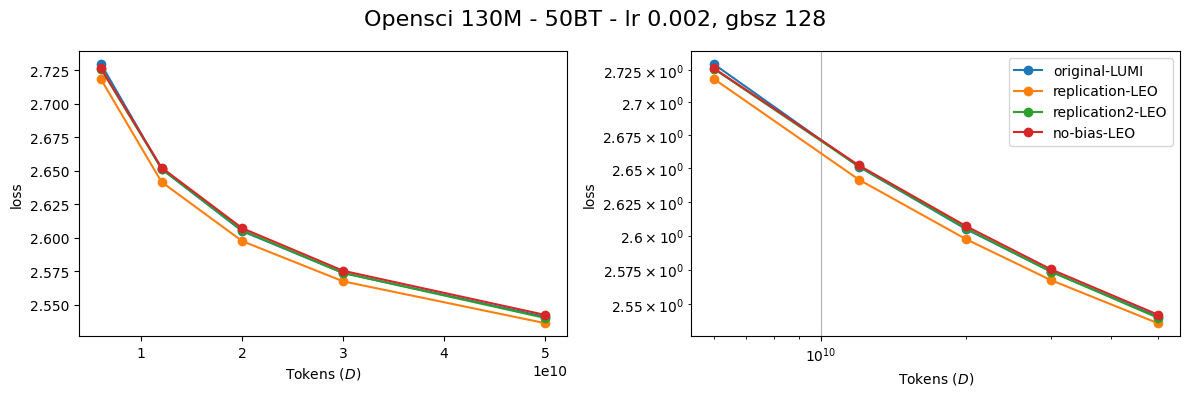

In [39]:
plot_loss_curves(
    models={
        "original-LUMI": opensci_130M_50BT_lr002_gbsz128,
        "replication-LEO": opensci_replication_130M_50BT_lr002_gbsz128,
        "replication2-LEO": opensci_replication2_130M_50BT_lr002_gbsz128,
        "no-bias-LEO": opensci_no_bias_130M_50BT_lr002_gbsz128,
    },
    x_axis="tokens",
    title_base="Opensci 130M - 50BT - lr 0.002, gbsz 128",
    save_path="figures/token_loss_no_bias_opensci_130M_5BT_lr002_gbsz128.png",
    figsize=(12, 4)
)

### GQA experiment

In [22]:
opensci_gqa_130M_50BT_lr002_gbsz128 = pd.read_csv("results/tests/eval_opensci_gqa_130M_50BT/val_loss_summary.csv")
opensci_gqa_130M_50BT_lr002_gbsz128["gbsz"] = 128
opensci_gqa_130M_50BT_lr002_gbsz128["lr"] = 0.002
opensci_gqa_130M_50BT_lr002_gbsz128["non_embed_params (B)"] = 0.09
opensci_gqa_130M_50BT_lr002_gbsz128["params (B)"] = 0.13
opensci_gqa_130M_50BT_lr002_gbsz128["parameters"] = 118702944
opensci_gqa_130M_50BT_lr002_gbsz128["model_name"] = "opensci-gqa-130M-50BT-lr002-gbsz128"
opensci_gqa_130M_50BT_lr002_gbsz128 = calc_toks_flops(opensci_gqa_130M_50BT_lr002_gbsz128)
opensci_gqa_130M_50BT_lr002_gbsz128.head(2)

,run_name,iteration,lm_loss,lm_loss_ppl,gbsz,lr,non_embed_params (B),params (B),parameters,model_name,tokens (B),compute (exaFLOPs),compute (FLOPs)
4,eval_opensci_gqa_130M_50BT_lr0.002_gbsz128_bet...,11445,2.741812,15.51508,128,0.002,0.09,0.13,118702944,opensci-gqa-130M-50BT-lr002-gbsz128,6.000476,3.240257,3.240257e+18
0,eval_opensci_gqa_130M_50BT_lr0.002_gbsz128_bet...,22889,2.664138,14.35557,128,0.002,0.09,0.13,118702944,opensci-gqa-130M-50BT-lr002-gbsz128,12.000428,6.480231,6.480231e+18


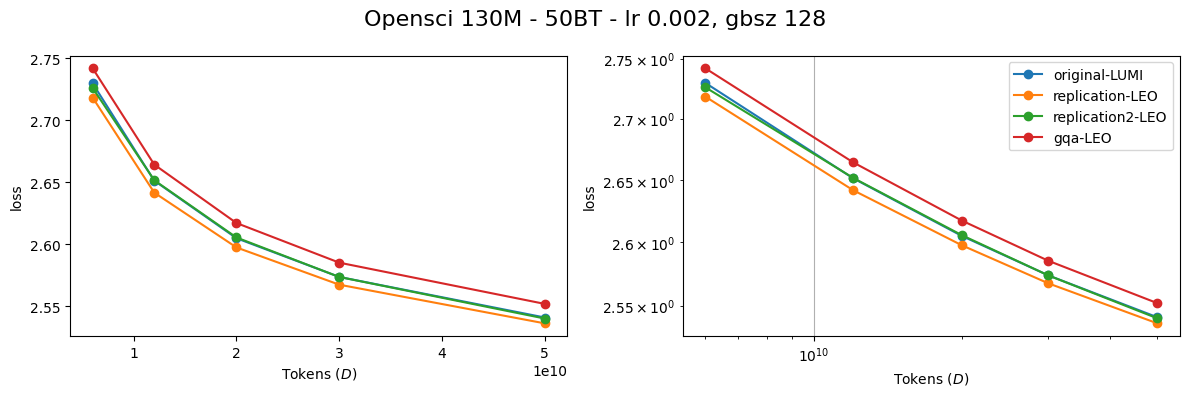

In [40]:
plot_loss_curves(
    models={
        "original-LUMI": opensci_130M_50BT_lr002_gbsz128,
        "replication-LEO": opensci_replication_130M_50BT_lr002_gbsz128,
        "replication2-LEO": opensci_replication2_130M_50BT_lr002_gbsz128,
        "gqa-LEO": opensci_gqa_130M_50BT_lr002_gbsz128,
    },
    x_axis="tokens",
    title_base="Opensci 130M - 50BT - lr 0.002, gbsz 128",
    save_path="figures/token_loss_gqa_opensci_130m_5bt.png",
    figsize=(12, 4)
)

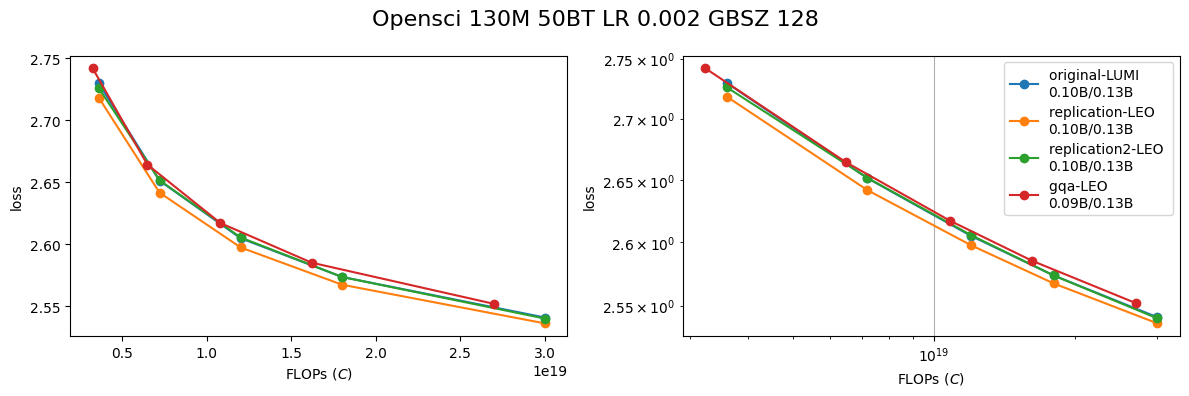

In [48]:
plot_loss_curves(
    models={
        "original-LUMI \n0.10B/0.13B": opensci_130M_50BT_lr002_gbsz128,
        "replication-LEO \n0.10B/0.13B": opensci_replication_130M_50BT_lr002_gbsz128,
        "replication2-LEO \n0.10B/0.13B": opensci_replication2_130M_50BT_lr002_gbsz128,
        "gqa-LEO \n0.09B/0.13B": opensci_gqa_130M_50BT_lr002_gbsz128,
    },
    x_axis="compute",
    title_base="Opensci 130M 50BT LR 0.002 GBSZ 128",
    save_path="figures/compute_loss_gqa_opensci_130m_5bt.png",
    figsize=(12, 4)
)

### Qwen3 experiments

In [32]:
qwen3_150M = pd.read_csv("results/eval_qwen3_150M_gpt_neox/val_loss_summary.csv")
gbsz_tmp = []
lr_tmp = []
for run_name in qwen3_150M.run_name.to_list():
    gbsz = int(run_name.split("gbsz")[1].split("_")[0])
    gbsz_tmp.append(gbsz)

    lr = float(run_name.split("lr")[1].split("_")[0])
    lr_tmp.append(lr)
qwen3_150M["gbsz"] = gbsz_tmp
qwen3_150M["lr"] = lr_tmp
qwen3_150M["non_embed_params (B)"] = 0.05
qwen3_150M["params (B)"] = 0.08
qwen3_150M["parameters"] = 76106240
qwen3_150M["model_name"] = "qwen3-150M-gpt-neox"
qwen3_150M = calc_toks_flops(qwen3_150M)
qwen3_150M.head(2)

,run_name,iteration,lm_loss,lm_loss_ppl,gbsz,lr,non_embed_params (B),params (B),parameters,model_name,tokens (B),compute (exaFLOPs),compute (FLOPs)
1,eval_dense_qwen3_150M_gpt_neox_lr0.001_gbsz32_...,45777,2.820609,16.78706,32,0.001,0.05,0.08,76106240,qwen3-150M-gpt-neox,6.000083,1.800025,1.800025e+18
0,eval_dense_qwen3_150M_gpt_neox_lr0.001_gbsz32_...,91553,2.758214,15.77166,32,0.001,0.05,0.08,76106240,qwen3-150M-gpt-neox,12.000035,3.600010,3.600010e+18


In [33]:
qwen3_300M = pd.read_csv("results/eval_qwen3_300M_gpt_neox/val_loss_summary.csv")
gbsz_tmp = []
lr_tmp = []
for run_name in qwen3_300M.run_name.to_list():
    gbsz = int(run_name.split("gbsz")[1].split("_")[0])
    gbsz_tmp.append(gbsz)
    lr = float(run_name.split("lr")[1].split("_")[0])
    lr_tmp.append(lr)
qwen3_300M["gbsz"] = gbsz_tmp
qwen3_300M["lr"] = lr_tmp
qwen3_300M["non_embed_params (B)"] = 0.16
qwen3_300M["params (B)"] = 0.19
qwen3_300M["parameters"] = 194385792
qwen3_300M["model_name"] = "qwen3-300M-gpt-neox"
qwen3_300M = calc_toks_flops(qwen3_300M)    
qwen3_300M.head(2)

,run_name,iteration,lm_loss,lm_loss_ppl,gbsz,lr,non_embed_params (B),params (B),parameters,model_name,tokens (B),compute (exaFLOPs),compute (FLOPs)
3,eval_dense_qwen3_300M_gpt_neox_lr0.0005_gbsz64...,22889,2.643505,14.06240,64,0.0005,0.16,0.19,194385792,qwen3-300M-gpt-neox,6.000214,5.760205,5.760205e+18
0,eval_dense_qwen3_300M_gpt_neox_lr0.0005_gbsz64...,45777,2.570333,13.07018,64,0.0005,0.16,0.19,194385792,qwen3-300M-gpt-neox,12.000166,11.520159,1.152016e+19


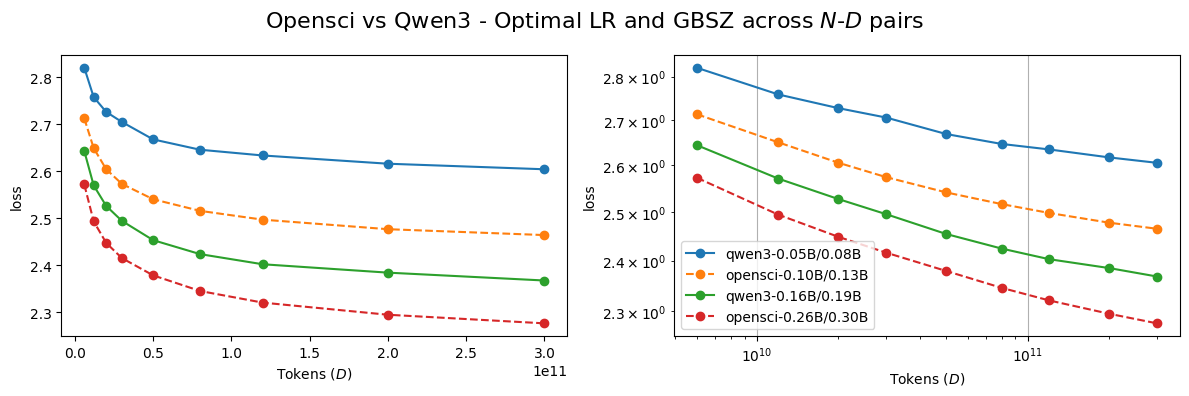

In [57]:
def style_fn(label, _):
    return {"linestyle": "--"} if "opensci" in label else {}
plot_loss_curves(
    models={
        "qwen3-0.05B/0.08B": qwen3_150M,
        "opensci-0.10B/0.13B": opensci_130M,
        "qwen3-0.16B/0.19B": qwen3_300M,
        "opensci-0.26B/0.30B": opensci_300M,
    },
    x_axis="tokens",
    title_base="Opensci vs Qwen3 - Optimal LR and GBSZ across $N$-$D$ pairs",
    save_path="figures/token_loss_opensci_qwen3.png",
    style_fn=style_fn,
    figsize=(12, 4)
)

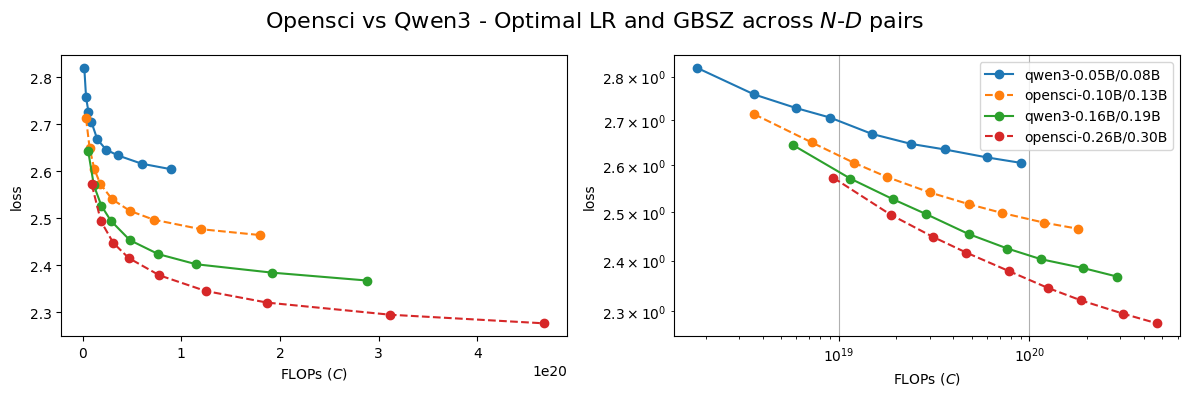

In [58]:
def style_fn(label, _):
    return {"linestyle": "--"} if "opensci" in label else {}
plot_loss_curves(
    models={
        "qwen3-0.05B/0.08B": qwen3_150M,
        "opensci-0.10B/0.13B": opensci_130M,
        "qwen3-0.16B/0.19B": qwen3_300M,
        "opensci-0.26B/0.30B": opensci_300M,
    },
    x_axis="compute",
    title_base="Opensci vs Qwen3 - Optimal LR and GBSZ across $N$-$D$ pairs",
    save_path="figures/compute_loss_opensci_qwen3.png",
    style_fn=style_fn,
    figsize=(12, 4)
)